In [1]:
import astropy.units as u
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snewpy.models.ccsn as models
import ipywidgets as widgets

from ipywidgets import interact
from IPython.display import Markdown
from snewpy.neutrino import Flavor
from snewpy.rate_calculator import RateCalculator

from scipy.integrate import quad

from src import ibd
from src import es

In [2]:
models.all_models

{snewpy.models.ccsn.Bollig_2016,
 snewpy.models.ccsn.Bugli_2021,
 snewpy.models.ccsn.Fischer_2020,
 snewpy.models.ccsn.Fornax_2019,
 snewpy.models.ccsn.Fornax_2021,
 snewpy.models.ccsn.Fornax_2022,
 snewpy.models.ccsn.Kuroda_2020,
 snewpy.models.ccsn.Mori_2023,
 snewpy.models.ccsn.Nakazato_2013,
 snewpy.models.ccsn.OConnor_2013,
 snewpy.models.ccsn.OConnor_2015,
 snewpy.models.ccsn.Sukhbold_2015,
 snewpy.models.ccsn.Tamborra_2014,
 snewpy.models.ccsn.Walk_2018,
 snewpy.models.ccsn.Walk_2019,
 snewpy.models.ccsn.Warren_2020,
 snewpy.models.ccsn.Zha_2021,
 snewpy.models.presn.Kato_2017,
 snewpy.models.presn.Odrzywolek_2010,
 snewpy.models.presn.Patton_2017,
 snewpy.models.presn.Yoshida_2016}

# Organizar modelos

In [2]:
# Lista modelos de interés
modelos_obj = {
    'Nakazato_2013': models.Nakazato_2013,
    'Sukhbold_2015': models.Sukhbold_2015,
    'Tamborra_2014': models.Tamborra_2014, 
    'Bollig_2016' : models.Bollig_2016,
    'OConnor_2015' : models.OConnor_2015,
}

catalogo_modelos = {
    nombre: clase.get_param_combinations()
    for nombre, clase in modelos_obj.items()
}

def mostrar_opciones():
    """
    Imprime el catálogo de modelos y la combinación de parámetros disponibles.
    """
    print(f"{'MODELO':<20} | {'COMBINACIONES DISPONIBLES'}")
    print("-" * 60)
    for nombre, combos in catalogo_modelos.items():
        print(f"{nombre:<20} | {len(combos)} combinaciones encontradas.")

# Modelos y total de opciones
mostrar_opciones()

MODELO               | COMBINACIONES DISPONIBLES
------------------------------------------------------------
Nakazato_2013        | 24 combinaciones encontradas.
Sukhbold_2015        | 4 combinaciones encontradas.
Tamborra_2014        | 5 combinaciones encontradas.
Bollig_2016          | 2 combinaciones encontradas.
OConnor_2015         | 1 combinaciones encontradas.


In [8]:
def listar_combinaciones(nombre_modelo):
    """
    Muestra todas las opciones para un modelo específico.
    """
    combos = catalogo_modelos.get(nombre_modelo)
    if combos:
        df = pd.DataFrame(combos)
        print(f"Opciones disponibles para {nombre_modelo}:")
        display(df)
    else:
        print("Modelo no encontrado.")


# Ejemplo
listar_combinaciones('Bollig_2016')

modelo_act = ''

Opciones disponibles para Bollig_2016:


,progenitor_mass,eos
0,11.2 solMass,LS220
1,27.0 solMass,LS220


In [9]:
def cargar_modelo(nombre_modelo, indice_comb):
    """
    Instancia un modelo de snewpy usando el diccionario de combinaciones.
    """
    clase_modelo = modelos_obj[nombre_modelo]
    parametros = catalogo_modelos[nombre_modelo][indice_comb]

    global modelo_act
    modelo_act = nombre_modelo
    
    return clase_modelo(**parametros)

# EJEMPLO
mi_modelo = cargar_modelo('Bollig_2016', 0)

mi_modelo.time

/tmp/ipykernel_12112/4140367241.py:11: UserWarning: Argument `eos` is deprecated.
  return clase_modelo(**parametros)


<Quantity [-0.17009297, -0.16907753, -0.16805314, ...,  7.6003497 ,
            7.60043864,  7.6004785 ] s>

# Características espectrales

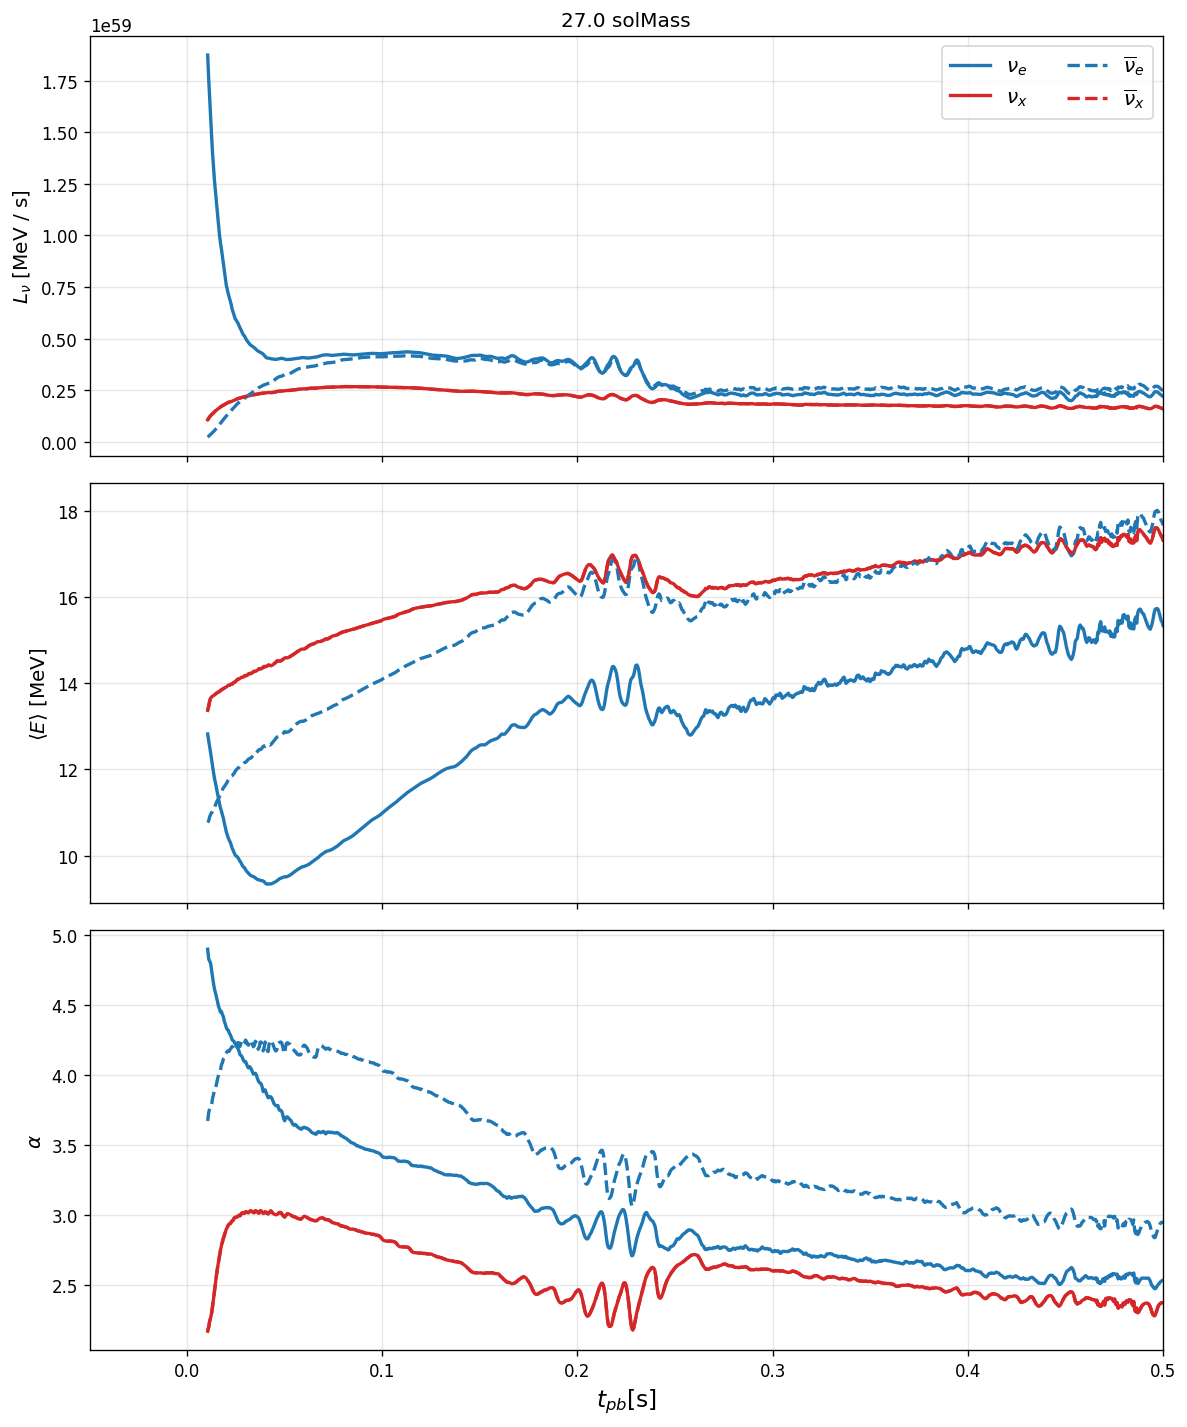

In [6]:
def graficar_cantidades_modelo(modelo):
    """
    Extrae y grafica la luminosidad, energía media y parámetro pinch
    en la neutrinósfera.
    """    
    t = modelo.time
    
    # subplots verticales
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, 
                                        figsize=(10, 12), 
                                        sharex=True, 
                                        dpi=120)
    
    # Luminosidad (MeV/s) 
    for flavor in Flavor:
        ax1.plot(t, modelo.luminosity[flavor].to(u.MeV / u.s), 
                 color='C0' if flavor.is_electron else 'C3',
                 ls='-' if flavor.is_neutrino else '--',
                 lw=2, 
                 label=flavor.to_tex())
        
    ax1.set_ylabel(r'$L_{\nu}$ ' f'[{modelo.luminosity[Flavor.NU_E].to(u.MeV / u.s).unit}]', 
                   fontsize=12)
    ax1.set_title(f'{modelo.metadata.get("Progenitor mass", "CCSN")}')
    ax1.grid(alpha=0.3)
    ax1.legend(loc='upper right', ncol=2, fontsize=12)

    # Energía media (MeV)
    for flavor in Flavor:
        ax2.plot(t, modelo.meanE[flavor].to(u.MeV), 
                 color='C0' if flavor.is_electron else 'C3',
                 ls='-' if flavor.is_neutrino else '--',
                 lw=2)
                 
    ax2.set_ylabel(rf'$\langle E \rangle$ [{modelo.meanE[Flavor.NU_E].to(u.MeV).unit}]', 
                   fontsize=12)
    ax2.grid(alpha=0.3)

    # Parámetro pinch
    for flavor in Flavor:
        ax3.plot(t, modelo.pinch[flavor], 
                 color='C0' if flavor.is_electron else 'C3',
                 ls='-' if flavor.is_neutrino else '--',
                 lw=2)
                 
    ax3.set_ylabel(rf'$\alpha$', 
                   fontsize=12)
    ax3.set_xlabel(r'$t_{pb}$' + f'[{t.unit}]', 
                   fontsize=14)
    ax3.grid(alpha=0.3)

    ax3.set_xlim(-0.05, 0.5) 
    
    plt.tight_layout()
    plt.show()

graficar_cantidades_modelo(mi_modelo)

# Cálculo neutrinósferas
$$
\Large
L_{\nu_{x}} = 4\pi\phi\sigma_{\nu}\,T^{4}_{\nu}R^{2}_{\nu}
$$

$$
\Large
R_{\nu} = \sqrt{\frac{L_{\nu_{x}}}{4\pi\phi\sigma_{\nu}T^{4}_{\nu}}} 
$$

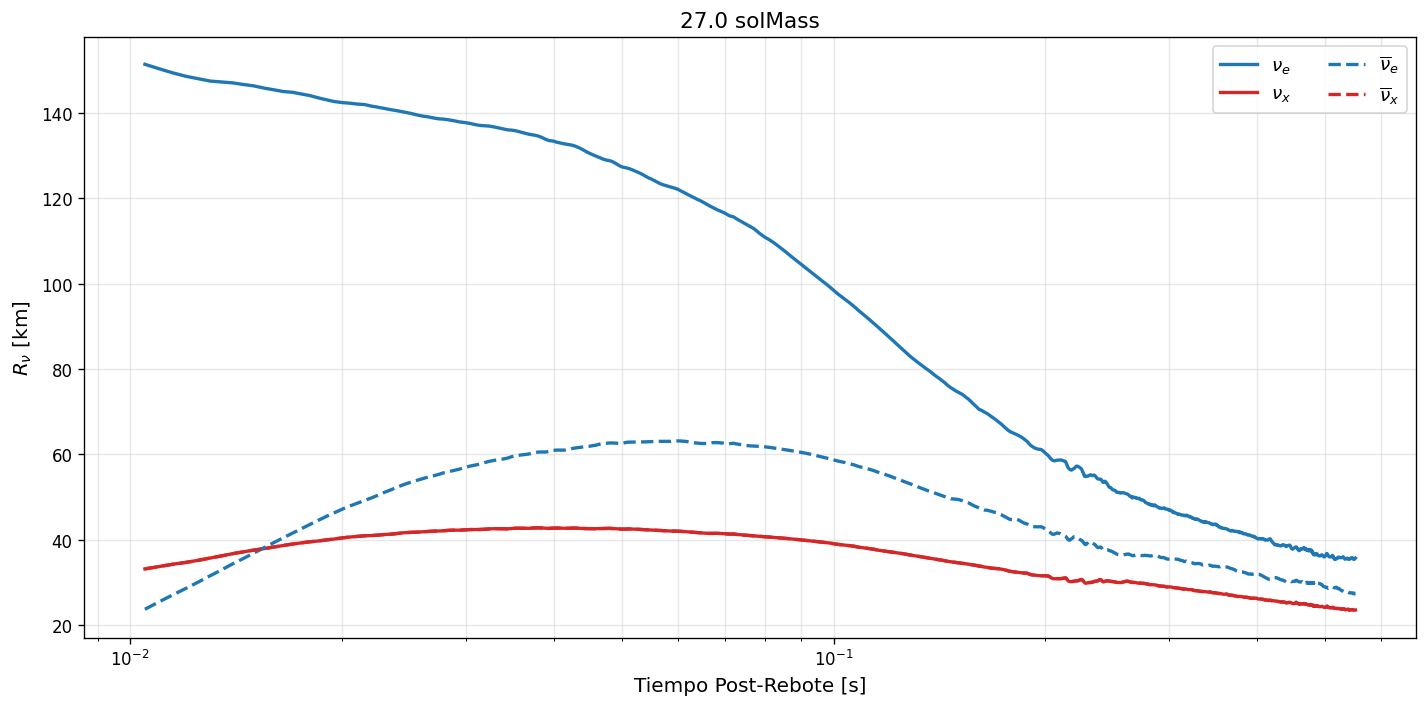

In [7]:
def graficar_radio_neutrinosfera(modelo):
    """
    Calcula y grafica la evolución temporal del radio 
    de la neutrinosfera para el modelo CCSN cargado.
    """
    
    # Definiciones
    sigmanu = 4.751e+35 * u.erg / (u.MeV**4 * u.cm**2 * u.s)
    phigray = 0.8  # 0.4 - 0.8
    
    # Temperatura efectiva
    tempe = {flavor: energia / 3.1514 for flavor, energia in modelo.meanE.items()}

    radion = {flavor: np.sqrt(luminosidad/(4*np.pi*phigray*sigmanu*(tempe[flavor]**4))).to(u.km)
             for flavor, luminosidad in modelo.luminosity.items()}

    plt.figure(figsize=(12, 6), dpi=120)
    
    for flavor in Flavor:
        plt.plot(modelo.time, radion[flavor], 
                 label=flavor.to_tex(),
                 color='C0' if flavor.is_electron else 'C3',
                 ls='-' if flavor.is_neutrino else '--', lw=2)
                 
    plt.xscale('log')
    plt.xlabel(f'Tiempo Post-Rebote [{modelo.time.unit}]', fontsize=12)
    plt.ylabel(f'$R_\\nu$ [{radion[Flavor.NU_E].unit}]', fontsize=12)
    plt.title(f'{modelo.metadata.get("Progenitor mass", "CCSN")}', 
              fontsize=13)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(loc='upper right', ncol=2, fontsize=11)
    
    plt.tight_layout()
    plt.show()

graficar_radio_neutrinosfera(mi_modelo)

# Flujos en Tierra para ambas jerarquías (Manual)

In [8]:
"""
DEFINICIONES
"""
# Cada opción del dropdown tiene un P_H asociado
diccionario_PH = {
    'Adiabática (PH = 0)':     0.0,
    'Mixta (PH = 0.5)':        0.5,
    'No Adiabática (PH = 1)':  1.0,
}

# energiatest = np.arange(0.1, 60.5, 0.5) * u.MeV 
energiatest = np.linspace(0.1, 60, 200) * u.MeV
t = mi_modelo.time

# Diccionario con el espectro inicial (neutrinósfera) en todo el tiempo de la simulación 
espectro_aux = mi_modelo.get_initial_spectra(t, energiatest)
espectro = {flavor: data.to(1/(u.MeV*u.s)) for flavor, data in espectro_aux.items()}

"""
ALGUNAS FUNCIOES
"""

def calcular_probabilidades(P_H, jerarquia):
    """
    Calcula p y p_bar usando las fórmulas de Dighe-Smirnov con P_L = 0.

    NMO:
        p     = |Ue2|² * P_H + |Ue3|² * (1 - P_H)
        p_bar = |Ue1|²
    IMO:
        p     = |Ue2|²
        p_bar = |Ue1|² * P_H + |Ue3|² * (1 - P_H)
    """
    angulos = {
        'Normal (NMO)':    (33.76, 8.62, 43.29),
        'Invertida (IMO)': (33.76, 8.65, 47.90),
    }
    
    t12, t13, t23 = [np.deg2rad(a) for a in angulos[jerarquia]]

    Ue1_sq = np.cos(t12)**2 * np.cos(t13)**2
    Ue2_sq = np.sin(t12)**2 * np.cos(t13)**2
    Ue3_sq = np.sin(t13)**2

    if jerarquia == 'Normal (NMO)':
        p     = Ue2_sq * P_H + Ue3_sq * (1.0 - P_H)
        p_bar = Ue1_sq

    elif jerarquia == 'Invertida (IMO)':
        p     = Ue2_sq
        p_bar = Ue1_sq * P_H + Ue3_sq * (1.0 - P_H)

    return p, p_bar


def calcular_flujo_tierra(P_H, distancia_kpc = 10): # Se podría añadir un slider que controle la distancia a la supernova
    """
    Calcula los flujos en la Tierra (flujo_nmo, flujo_imo) a partir de una probabilidad ph
    """
    distancia = (distancia_kpc*u.kpc).to(u.cm)
    factor_T = 1/(4*np.pi*distancia**2)

    psurvival_nmo, psurvival_bar_nmo = calcular_probabilidades(P_H, 'Normal (NMO)')
    psurvival_imo, psurvival_bar_imo = calcular_probabilidades(P_H, 'Invertida (IMO)')

    # NMO
    flujo_tierra_nmo = {sabor: None for sabor in Flavor}
    
    # Flujo en Tierra (tiempo x energía)
    flujo_tierra_nmo[Flavor.NU_E] = (psurvival_nmo*espectro[Flavor.NU_E] + (1-psurvival_nmo)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra_nmo[Flavor.NU_X] = (1/2)*((1-psurvival_nmo)*espectro[Flavor.NU_E] + (1+psurvival_nmo)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra_nmo[Flavor.NU_E_BAR] = (psurvival_bar_nmo*espectro[Flavor.NU_E_BAR] + (1-psurvival_bar_nmo)*espectro[Flavor.NU_X_BAR]) * factor_T
    flujo_tierra_nmo[Flavor.NU_X_BAR] = (1/2)*((1-psurvival_bar_nmo)*espectro[Flavor.NU_E_BAR] + (1+psurvival_bar_nmo)*espectro[Flavor.NU_X_BAR]) * factor_T

    # IMO
    flujo_tierra_imo = {sabor: None for sabor in Flavor}
    
    # Flujo en Tierra (tiempo x energía)
    flujo_tierra_imo[Flavor.NU_E] = (psurvival_imo*espectro[Flavor.NU_E] + (1-psurvival_imo)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra_imo[Flavor.NU_X] = (1/2)*((1-psurvival_imo)*espectro[Flavor.NU_E] + (1+psurvival_imo)*espectro[Flavor.NU_X]) * factor_T
    flujo_tierra_imo[Flavor.NU_E_BAR] = (psurvival_bar_imo*espectro[Flavor.NU_E_BAR] + (1-psurvival_bar_imo)*espectro[Flavor.NU_X_BAR]) * factor_T
    flujo_tierra_imo[Flavor.NU_X_BAR] = (1/2)*((1-psurvival_bar_imo)*espectro[Flavor.NU_E_BAR] + (1+psurvival_bar_imo)*espectro[Flavor.NU_X_BAR]) * factor_T


    return flujo_tierra_nmo, flujo_tierra_imo

## Comparado con la neutrinósfera

In [9]:
"""
PLOT INTERACTIVO
"""
def flujo_tierra_widget(tiempoS, nombre_transformacion, jerarquia, distancia_kpc=10): # Se podría añadir un slider que controle la distancia a la supernova

    display(f"Tiempo: {t[tiempoS]}")

    distancia = (distancia_kpc*u.kpc).to(u.cm)
    factor_T = 1/(4*np.pi*distancia**2)

    # Escenario P_H y probabilidades
    P_H = diccionario_PH[nombre_transformacion]
    psurvival, psurvival_bar = calcular_probabilidades(P_H, jerarquia)

    # Espectro inicial (neutrinósfera) en cada tiempoS
    espectro_temp = {flavor: data[tiempoS] for flavor, data in espectro.items()}

    # # Flujos en Tierra deprecated, ahora se hace en una función
    # flujo_tierra = {sabor: None for sabor in Flavor}
    # # Conservación de flujo y factor geométrico
    # flujo_tierra[Flavor.NU_E] = (psurvival*espectro[Flavor.NU_E] + (1-psurvival)*espectro[Flavor.NU_X]) * factor_T
    # flujo_tierra[Flavor.NU_X] = (1/2)*((1-psurvival)*espectro[Flavor.NU_E] + (1+psurvival)*espectro[Flavor.NU_X]) * factor_T
    # flujo_tierra[Flavor.NU_E_BAR] = (psurvival_bar*espectro[Flavor.NU_E_BAR] + (1-psurvival_bar)*espectro[Flavor.NU_X_BAR]) * factor_T
    # flujo_tierra[Flavor.NU_X_BAR] = (1/2)*((1-psurvival_bar)*espectro[Flavor.NU_E_BAR] + (1+psurvival_bar)*espectro[Flavor.NU_X_BAR]) * factor_T

    flujo_nmo, flujo_imo = calcular_flujo_tierra(P_H)
    flujo_tierra = flujo_nmo if jerarquia == 'Normal (NMO)' else flujo_imo

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

    # Espectro inicial en la neutrinósfera
    for flavor in Flavor:
        ax1.plot(
            energiatest,
            espectro_temp[flavor],
            color = 'C0' if flavor.is_electron else 'C3',
            ls    = '-'  if flavor.is_neutrino  else '--',
            lw    = 2,
            label = flavor.to_tex()
        )

    ax1.set_title('Espectro Inicial (Neutrinósfera)')
    ax1.set_xlabel(f'E [{energiatest.unit}]')
    ax1.set_ylabel(f'[{espectro_temp[Flavor.NU_E][0].unit}]')
    ax1.grid(alpha=0.3)
    ax1.legend(loc='upper right', ncol=2, fontsize=11)

    # Flujo en la Tierra (NO-SNEWPY)
    for flavor in Flavor:
        ax2.plot(
            energiatest,
            flujo_tierra[flavor][tiempoS],
            color = 'C0' if flavor.is_electron else 'C3',
            ls    = '-'  if flavor.is_neutrino  else '--',
            lw    = 2,
            label = flavor.to_tex()
        )

    ax2.set_title(
        f'Flujo en la Tierra | {nombre_transformacion} | {jerarquia}'
        # f'$\np = {psurvival:.4f}$,  $\\bar{{p}} = {psurvival_bar:.4f}$'
    )
    ax2.set_xlabel(f'E [{energiatest.unit}]')
    ax2.set_ylabel(f'[{flujo_tierra[Flavor.NU_E][0].unit}]')
    ax2.grid(alpha=0.3)
    ax2.legend(loc='upper right', ncol=2, fontsize=11)

    plt.tight_layout()
    plt.show()

'''
WIDGETS
'''

tiempo_slider = widgets.IntSlider(
    value=120, min=0, max=len(mi_modelo.time)-1, step=1,
    description='Tiempo [idx]',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='850px')
)

transformacion_dropdown = widgets.Dropdown(
    options=list(diccionario_PH.keys()),
    value='Adiabática (PH = 0)',
    description='Transición:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='850px')
)

jerarquia_radio = widgets.RadioButtons(
    options=['Normal (NMO)', 'Invertida (IMO)'],
    value='Normal (NMO)',
    description='Jerarquía:',
    style={'description_width': '150px'}
)

controles = widgets.VBox([
    tiempo_slider,
    widgets.HBox(
        [transformacion_dropdown, jerarquia_radio],
        layout=widgets.Layout(gap='20px')
    )
])

salida = widgets.interactive_output(
    flujo_tierra_widget,
    {
        'tiempoS':              tiempo_slider,
        'nombre_transformacion': transformacion_dropdown,
        'jerarquia':         jerarquia_radio
    }
)

display(controles, salida)

Output()

## Flujo individual

In [10]:
"""
PLOT INTERACTIVO
"""
def flujo_tierra_widget(tiempoS, nombre_transformacion, jerarquia, distancia_kpc=10): # Se podría añadir un slider que controle la distancia a la supernova

    display(f"Tiempo: {t[tiempoS]}")

    distancia = (distancia_kpc*u.kpc).to(u.cm)
    factor_T = 1/(4*np.pi*distancia**2)

    # Escenario P_H y probabilidades
    P_H = diccionario_PH[nombre_transformacion]
    psurvival, psurvival_bar = calcular_probabilidades(P_H, jerarquia)

    # Espectro inicial (neutrinósfera) en cada tiempoS
    espectro_temp = {flavor: data[tiempoS] for flavor, data in espectro.items()}

    flujo_nmo, flujo_imo = calcular_flujo_tierra(P_H)
    flujo_tierra = flujo_nmo if jerarquia == 'Normal (NMO)' else flujo_imo
    
    # Plot
    plt.figure(figsize=(10, 6), dpi=120)

    for flavor in Flavor:
        plt.plot(energiatest, flujo_tierra[flavor][tiempoS], 
                 color = 'C0' if flavor.is_electron else 'C3', 
                 ls = '-'  if flavor.is_neutrino  else '--', 
                 lw = 2, 
                 label = flavor.to_tex()
                )

    plt.title(f'Flujo en la Tierra | {nombre_transformacion} | {jerarquia}')
    plt.xlabel(f'E [{energiatest.unit}]')
    plt.ylabel(f'[{flujo_tierra[Flavor.NU_E][0].unit}]')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right', ncol=2, fontsize=11)
    plt.tight_layout()
    plt.show()

'''
WIDGETS
'''

tiempo_slider = widgets.IntSlider(
    value=120, min=0, max=len(mi_modelo.time)-1, step=1,
    description='Tiempo [idx]',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='850px')
)

transformacion_dropdown = widgets.Dropdown(
    options=list(diccionario_PH.keys()),
    value='Adiabática (PH = 0)',
    description='Transición:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='850px')
)

jerarquia_radio = widgets.RadioButtons(
    options=['Normal (NMO)', 'Invertida (IMO)'],
    value='Normal (NMO)',
    description='Jerarquía:',
    style={'description_width': '150px'}
)

controles = widgets.VBox([
    tiempo_slider,
    widgets.HBox(
        [transformacion_dropdown, jerarquia_radio],
        layout=widgets.Layout(gap='20px')
    )
])

salida = widgets.interactive_output(
    flujo_tierra_widget,
    {
        'tiempoS':              tiempo_slider,
        'nombre_transformacion': transformacion_dropdown,
        'jerarquia':         jerarquia_radio
    }
)

display(controles, salida)

Output()

# Secciones eficaces

In [11]:
"""
CONSTANTES
"""
factor_conversion = 3.894e-22 # MeV^-2 to cm^-2, util para DUNE

# Numero de blancos en cada detector
targets_hyperk_ibd = 1.2567e34 # Protones
targets_hyperk_nes = 6.28e+34 # Electrones

targets_juno_ibd = 1.432e+33 # Protones
targets_juno_nes = 6.76e+33 # Electrones

targets_dune_argon = 6.02e+32 # Argon 
targets_dune_nes = 1.08e+34 # Electrones

rc = RateCalculator()

Using snowglobes_data module ...


### $$\sigma(E_\nu) = \int_{E_{e, \text{min}}}^{E_{e, \text{max}}} \frac{d\sigma}{dE_e} (E_\nu, E_e)  \, dE_e$$

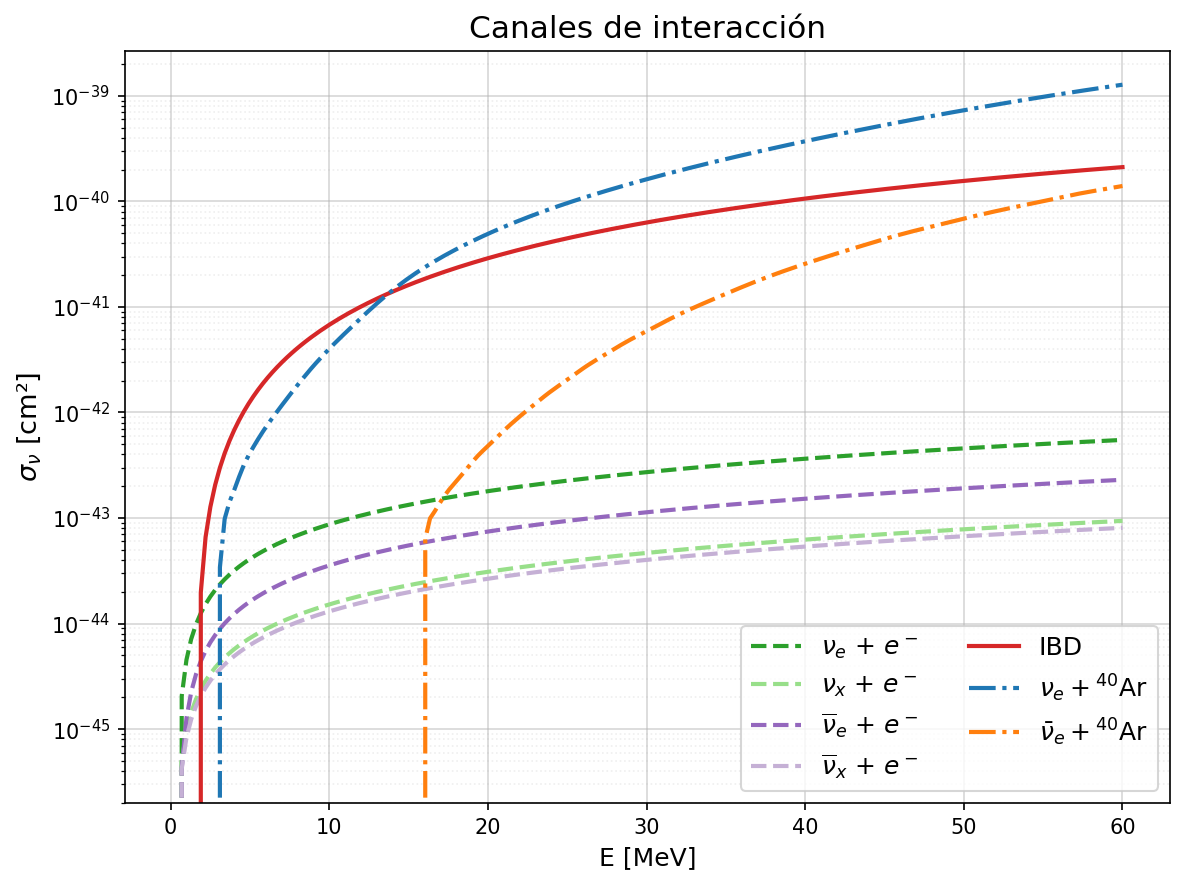

In [12]:
'''
NEUTRINO-ELECTRON SCATTERING
'''
# energias_nes = np.linspace(0.1, 60, 200)*u.MeV
# energias_nes = np.arange(0.1, 60.5, 0.5)*u.MeV

color_es = ['#2ca02c', '#98df8a', '#9467bd', '#c5b0d5'] # Verde y morado

xsec_es = {flavor: None for flavor in Flavor}

for flavor, color in zip(Flavor, color_es):
    canal_es = es.Channel(flavor)
    aux_es = []
    for E_nu in energiatest.value:
        eE_min, eE_max = canal_es.bounds_eE(E_nu)
        sigma = quad(lambda eE: canal_es.dSigma_dE(E_nu, eE) * factor_conversion, eE_min, eE_max)[0]
        aux_es.append(sigma)

    xsec_es[flavor] = np.array(aux_es) * u.cm**2

plt.figure(figsize=(8, 6), dpi=150)
for flavor, color in zip(Flavor, color_es):
    plt.plot(energiatest, xsec_es[flavor], 
             label=f'{flavor.to_tex()} + $e^-$', 
             color=color, 
             ls='--', 
             lw=2)
'''
INVERSE BETA DECAY
'''
# e_threshold = ibd.eThr # Sin unidades
# energias_ibd = np.linspace(e_threshold, 60, 200)*u.MeV
# energias_ibd = np.arange(e_threshold, 60.5+e_threshold, 0.5)*u.MeV

# Extraer sección eficaz
canal_ibd = ibd.Channel(Flavor.NU_E_BAR)

aux_ibd = []

for E_nu in energiatest.value:
    # Límites 
    eE_min, eE_max = canal_ibd.bounds_eE(E_nu)
    
    # Se integra la sección (dSigma/dE) 
    # quad devuelve una tupla (data, error)
    sigma_total = quad(lambda eE: canal_ibd.dSigma_dE(E_nu, eE) * factor_conversion, 
                       eE_min, eE_max)[0]
    
    # Se extraen los valores de quad[0] y se almacenan en una lista
    aux_ibd.append(sigma_total) # 

xsec_ibd = np.array(aux_ibd) * u.cm**2

plt.plot(energiatest, xsec_ibd, 
         color='#d62728', lw=2,
         label='IBD')
"""
INTERACCIONES EN ARGON
"""
# energias_Ar = np.linspace(0.1, 60, 200)*u.MeV
# energias_Ar = np.arange(0.1, 60.5, 0.5)*u.MeV

# snewpy/snowglobes 
xsec_arnue = rc.load_xsec('nue_Ar40', Flavor.NU_E)(energiatest)
xsec_arnuebar = rc.load_xsec('nuebar_Ar40', Flavor.NU_E_BAR)(energiatest)

plt.plot(energiatest, xsec_arnue, label=r'$\nu_e + ^{40}\mathrm{Ar}$', ls='-.', color='#1f77b4', lw = 2)
plt.plot(energiatest, xsec_arnuebar, label=r'$\bar{\nu}_e + ^{40}\mathrm{Ar}$', ls='-.', color='#ff7f0e', lw=2)

plt.yscale('log')
plt.xlabel('E [MeV]', fontsize=12)
plt.ylabel(r'$\sigma_\nu$ [cm²]', fontsize=13)
plt.title('Canales de interacción', fontsize=15)
plt.legend(loc='lower right', ncol=2, fontsize=12, 
           framealpha=0.8)

plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.grid(True, which='minor', linestyle=':', alpha=0.2) 

plt.tight_layout()
# plt.savefig('images/xsecs', dpi=300, bbox_inches='tight')
plt.show()

# Tasas de eventos

In [13]:
canales_deteccion = {
    
    # CANALES IBD

    'Hyper-K | Canal IBD ': {
        'targets': targets_hyperk_ibd,
        'xsec': xsec_ibd,
        'flavor': Flavor.NU_E_BAR,
        'tipo': 'cc' 
    },
    'JUNO | Canal IBD': {
        'targets': targets_juno_ibd,
        'xsec': xsec_ibd,
        'flavor': Flavor.NU_E_BAR,
        'tipo': 'cc'
    },
    
    # CANALES EN ARGÓN (CC)

    'DUNE | Canal \u03BD\u2091 CC': { # Unicode HTML
        'targets': targets_dune_argon,
        'xsec': xsec_arnue,
        'flavor': Flavor.NU_E,
        'tipo': 'cc'
    },
    'DUNE | Canal \u03BD\u0304\u2091 CC': { # Unicode HTML
        'targets': targets_dune_argon,
        'xsec': xsec_arnuebar,    
        'flavor': Flavor.NU_E_BAR,  
        'tipo': 'cc'
    },
    
    # ELECTRON SCATTERING
    
    'Hyper-K | Canal ES': { # (Agua 188 kt) 
        'targets': targets_hyperk_nes,
        'xsec': xsec_es, 
        'tipo': 'nc' 
    },
    'JUNO | Canal ES': { # (LS 20 kt)
        'targets': targets_juno_nes,
        'xsec': xsec_es,
        'tipo': 'nc'
    },
    'DUNE | Canal ES': { # (Ar 40 kt)
        'targets': targets_dune_nes,
        'xsec': xsec_es,
        'tipo': 'nc'
    }
}



    

In [14]:
def plot_eventos_general(nombre_transformacion, nombre_canal, distancia_kpc):

    # Flujos en Tierra
    P_H = diccionario_PH[nombre_transformacion]
    flujo_nmo, flujo_imo = calcular_flujo_tierra(P_H, distancia_kpc)

    # Detector en particular
    canal = canales_deteccion[nombre_canal]
    targets = canal['targets']

    # Canal en detector
    if canal['tipo'] == 'cc':
        flavor = canal['flavor']
        d2NdEdT_nmo = targets * flujo_nmo[flavor] * canal['xsec']
        d2NdEdT_imo = targets * flujo_imo[flavor] * canal['xsec']
        
    elif canal['tipo'] == 'nc':

        d2NdEdT_nmo = sum(targets * flujo_nmo[flavor] * canal['xsec'][flavor] for flavor in Flavor)
        d2NdEdT_imo = sum(targets * flujo_imo[flavor] * canal['xsec'][flavor] for flavor in Flavor)

    # Se integra en tiempo
    dNdE_nmo = np.trapezoid(d2NdEdT_nmo, x=t, axis=0)
    dNdE_imo = np.trapezoid(d2NdEdT_imo, x=t, axis=0)
    
    # Se integra en energías
    dNdT_nmo = np.trapezoid(d2NdEdT_nmo, x=energiatest, axis=1)
    dNdT_imo = np.trapezoid(d2NdEdT_imo, x=energiatest, axis=1)

    # Eventos totales
    total_nmo = np.trapezoid(dNdE_nmo, x=energiatest)
    total_imo = np.trapezoid(dNdE_imo, x=energiatest)

    # Gráficas
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)
    
    # Eventos en el tiempo
    ax1.plot(t, dNdT_nmo, lw=2.5, label=f'NMO (Total: {total_nmo:.0f})')
    ax1.plot(t, dNdT_imo, lw=2.5, linestyle='--', label=f'IMO (Total: {total_imo:.0f})')
    
    ax1.set_xlabel(r'$t_{pb}$ [s]', fontsize=12)
    ax1.set_ylabel(r'$\frac{dN}{dt}$ [' + str(dNdT_imo.unit) + ']', fontsize=12)
    # ax1.set_xlim(0.001, 10) 
    ax1.set_xlim(-0.05, 0.56) 
    # ax1.set_xscale('log') # Comentar para Tamborra
    ax1.grid(alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=11)

    # Eventos por energía
    ax2.plot(energiatest, dNdE_nmo, lw=2.5, label=f'NMO (Total: {total_nmo:.0f})')
    ax2.plot(energiatest, dNdE_imo, lw=2.5, linestyle='--', label=f'IMO (Total: {total_imo:.0f})')
    
    ax2.set_xlabel(r'$E_\nu$ [' + str(energiatest.unit) + ']', fontsize=12)
    ax2.set_ylabel(r'$\frac{dN}{dE_\nu}$ [' + str(dNdE_imo.unit) + ']', fontsize=12)
    # ax2.set_xlim(0.1, 60)
    ax2.grid(alpha=0.3, linestyle='--')
    ax2.legend(loc='upper right', fontsize=11)

    # Título
    fig.suptitle(f'{nombre_canal} | Transición: {nombre_transformacion} | d = {distancia_kpc:.2f} kpc \n {modelo_act}', 
                 fontsize=16, weight='bold')
    
    plt.tight_layout()
    plt.show()

"""
WIDGETS
"""

transformacion_dropdown = widgets.Dropdown(
    options=list(diccionario_PH.keys()),
    value='Adiabática (PH = 0)',
    description='Transición:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='300px')
)

canal_dropdown = widgets.Dropdown(
    options=list(canales_deteccion.keys()),
    value=list(canales_deteccion.keys())[0], 
    description='Detector: ',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='300px')
)

distancia_slider = widgets.FloatLogSlider(
    value=10.0,
    base=10,
    min=-1, # 0.1 kpc
    max=3,  # 1000 kpc
    step=0.05,
    description='Distancia [kpc]:',
    readout_format='.2f',
    style={'description_width': '110px'},
    layout=widgets.Layout(width='400px')
)

controlesf = widgets.HBox([canal_dropdown, transformacion_dropdown, distancia_slider])

salidaf = widgets.interactive_output(
    plot_eventos_general,
    {'nombre_transformacion': transformacion_dropdown,
     'nombre_canal': canal_dropdown,
     'distancia_kpc': distancia_slider}
)

display(mi_modelo.time) # Validar tiempo de modelo en la salida
display(controlesf, salidaf)

<Quantity [0.0105  , 0.011003, 0.011505, ..., 0.55062 , 0.55112 , 0.55162 ] s>

Output()

# Eventos totales

### $$ N(d) = \frac{C}{4\pi d^{2}}. \quad N(d_0 = 10\,\, \text{kpc} ) = \frac{C}{4 \pi d_{0}^{2}}$$ $$ \Leftrightarrow N (d) = N (d_0)\, \frac{d_0^{2}}{d^{2}} $$


In [15]:
def plot_eventos_kpc(nombre_transformacion, jerarquia):
    # probabilidad
    P_H = diccionario_PH[nombre_transformacion]

    distancias_kpc = np.logspace(-1, 3, 100)
    
    flujo_nmo_10kpc, flujo_imo_10kpc = calcular_flujo_tierra(P_H, distancia_kpc=10) # a 10 kpc 
    flujo_base = flujo_nmo_10kpc if jerarquia == 'Normal (NMO)' else flujo_imo_10kpc
        
    plt.figure(figsize=(12, 7), dpi=120)
    
    for nombre_canal, canal_info in canales_deteccion.items():
        targets = canal_info['targets']
        
        if canal_info['tipo'] == 'cc':
            flavor = canal_info['flavor']
            d2NdEdT = targets * flujo_base[flavor] * canal_info['xsec']
        elif canal_info['tipo'] == 'nc':
            d2NdEdT = sum(targets * flujo_base[flavor] * canal_info['xsec'][flavor] for flavor in Flavor)
            
        dNdE = np.trapezoid(d2NdEdT, x=t, axis=0)
        eventos_10kpc = np.trapezoid(dNdE, x=energiatest)
        
        eventos_kpc = eventos_10kpc * (10.0 / distancias_kpc)**2
        
        plt.plot(distancias_kpc, eventos_kpc, 
                 # lw=2.5, 
                 linestyle= '-' if canal_info['tipo'] == 'cc' else '--', 
                 label=nombre_canal
                )
        
    plt.xscale('log')
    plt.yscale('log')

    # Dict con distancias de interés
    referencias = {
        'Betelgeuse (0.2 kpc)': 0.2,
        'Vía Láctea (10 kpc)': 10,
        'Nube de Magallanes (50 kpc)': 50,
        'Andrómeda (765 kpc)': 765
    }
    colores_ref = ['#7f8c8d', '#2c3e50', '#8e44ad', '#c0392b'] 
    posicion_y = [10, 0.02, 2e3, 10]
    
    for (nombre, dist), color, ypos in zip(referencias.items(), colores_ref, posicion_y):
        
        plt.axvline(dist, color=color, linestyle=':', lw=1.5, alpha=0.7)
        plt.text(dist * 1.15, ypos, nombre, rotation=90, color=color, fontsize=11, verticalalignment='bottom')
                 
    plt.axhline(1, color='black', lw=1.5, linestyle='-.', alpha=0.5)
    plt.text(0.08, 1.3, "1 evento", color='black', alpha=0.7, fontsize=11)
    
    plt.xlabel('Distancia a la Supernova [kpc]', fontsize=13)
    plt.ylabel(f'Total de eventos', fontsize=13)
    plt.title(f'{jerarquia} | Transición: {nombre_transformacion}', 
              fontsize=16, weight='bold')
              
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    
    plt.tight_layout()
    plt.show()

"""
WIDGETS 
"""

transformacion_dropdown = widgets.Dropdown(
    options=list(diccionario_PH.keys()),
    value='Adiabática (PH = 0)',
    description='Transición:'
)

jerarquia_radio = widgets.RadioButtons(
    options=['Normal (NMO)', 'Invertida (IMO)'],
    value='Normal (NMO)',
    description='Jerarquía:',
    layout=widgets.Layout(width='300px')
)

controlese = widgets.HBox([transformacion_dropdown, jerarquia_radio], 
                            layout=widgets.Layout(margin='0 0 20px 0'))

salidae = widgets.interactive_output(
    plot_eventos_kpc,
    {'nombre_transformacion': transformacion_dropdown,
     'jerarquia': jerarquia_radio}
)

display(controlese, salidae)

Output()

# Gráficas adicionales o de apoyo

## 3 modelos

/tmp/ipykernel_46446/924983961.py:11: UserWarning: Argument `eos` is deprecated.
  return clase_modelo(**parametros)


**Sukhbold_2015 Model**: sukhbold-LS220-s27.0.fits

|Parameter|Value|
|:--------|:----:|
|Progenitor mass | $27$ $\mathrm{M_{\odot}}$|
|EOS | LS220 |

**Nakazato_2013 Model**: nakazato-shen-z0.02-t_rev200ms-s30.0.fits

|Parameter|Value|
|:--------|:----:|
|Progenitor mass | $30$ $\mathrm{M_{\odot}}$|
|Revival time | $200$ $\mathrm{ms}$|
|Metallicity | 0.02 |
|EOS | shen |

**Tamborra_2014 Model**

|Parameter|Value|
|:--------|:----:|
|EOS | LS220 |
|Progenitor mass | $27$ $\mathrm{M_{\odot}}$|
|Direction | 1 |

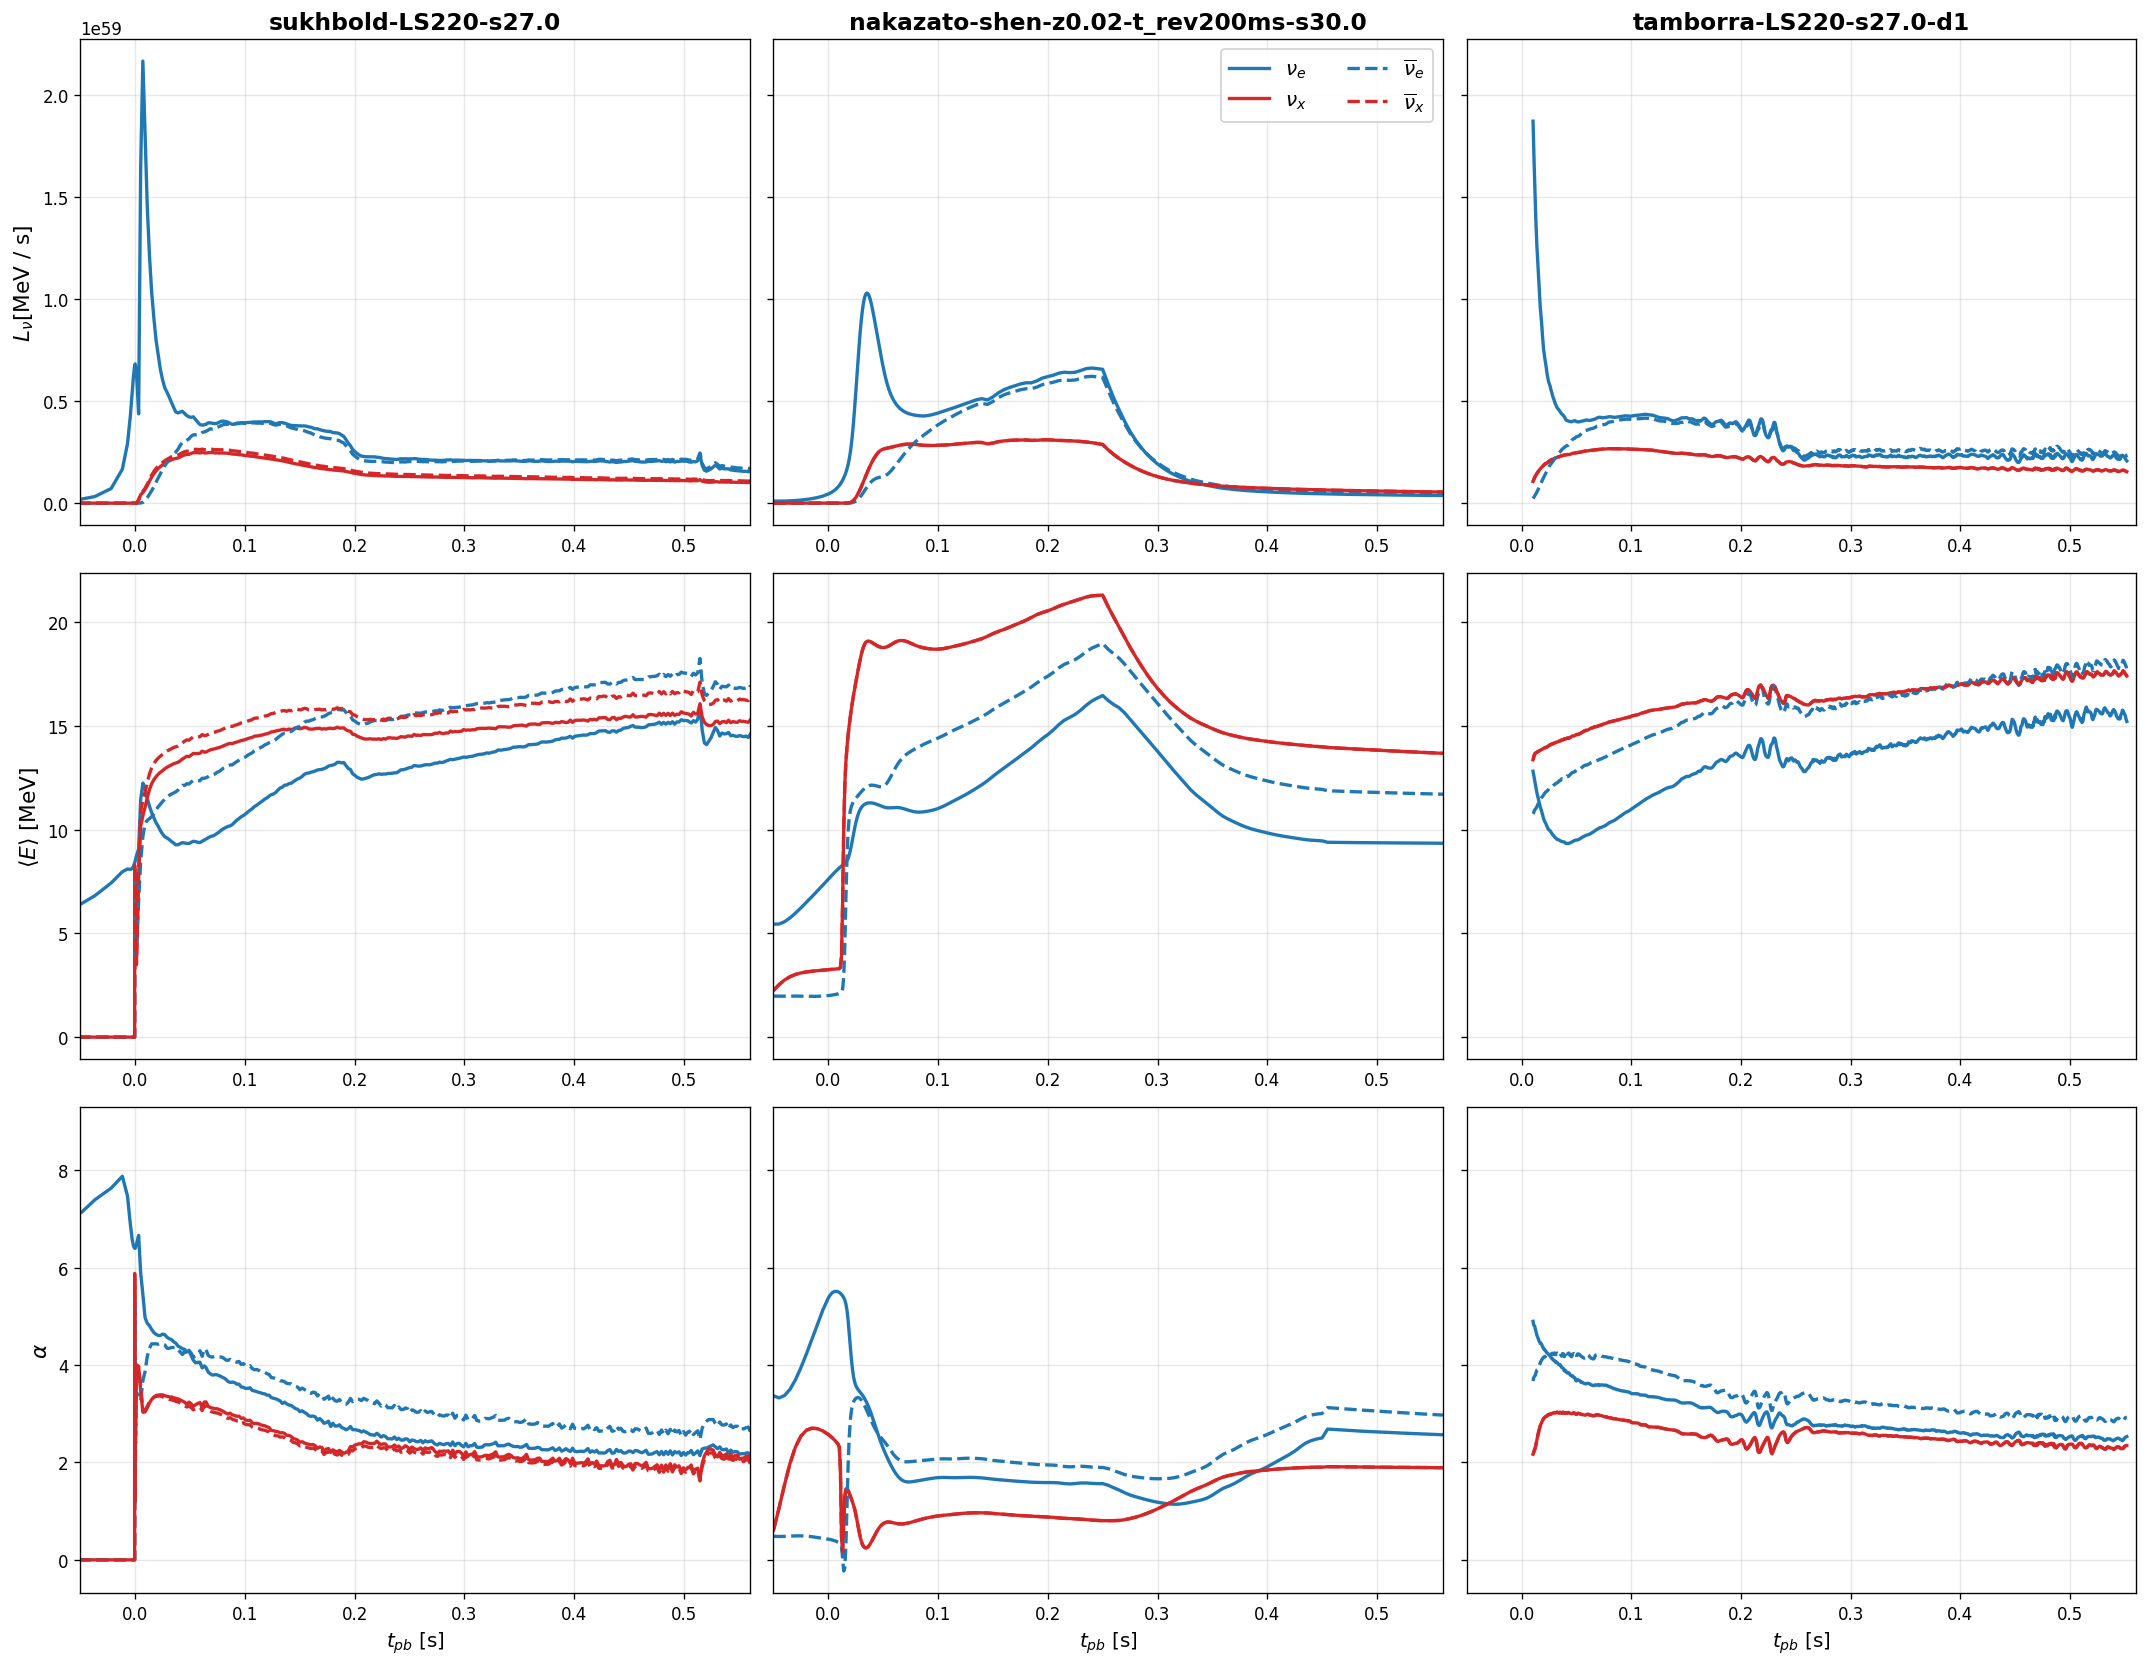

In [16]:
def graficar_3_modelos(diccionario_modelos):

    fig, axs = plt.subplots(3, 3, figsize=(18, 14), sharey='row', dpi=120)
    
    primer_modelo = list(diccionario_modelos.values())[0]
    uni_l = primer_modelo.luminosity[Flavor.NU_E].to(u.MeV / u.s).unit
    uni_e = primer_modelo.meanE[Flavor.NU_E].to(u.MeV).unit
    
    ylabels = [
        r'$L_{\nu} $' + f'[{uni_l}]',
        rf'$\langle E \rangle$ [{uni_e}]',
        rf'$\alpha$'
    ]

    for col_idx, (nombre_modelo, modelo) in enumerate(diccionario_modelos.items()):
        t = modelo.time
        
        ax_lum = axs[0, col_idx]
        ax_eng = axs[1, col_idx]
        ax_pnc = axs[2, col_idx]
        
        ax_lum.set_title(nombre_modelo, fontsize=14, weight='bold')

        for flavor in Flavor:
            color = 'C0' if flavor.is_electron else 'C3'
            ls = '-' if flavor.is_neutrino else '--'
            label_tex = flavor.to_tex() if col_idx == 1 else None # Solo etiqueta la primera columna
            
            ax_lum.plot(t, modelo.luminosity[flavor].to(u.MeV / u.s), 
                        color=color, ls=ls, lw=2, label=label_tex)
            
            ax_eng.plot(t, modelo.meanE[flavor].to(u.MeV), 
                        color=color, ls=ls, lw=2)
            
            ax_pnc.plot(t, modelo.pinch[flavor], 
                        color=color, ls=ls, lw=2)
            
        for row_idx, ax in enumerate([ax_lum, ax_eng, ax_pnc]):
            ax.grid(alpha=0.3)
            ax.set_xlim(-0.05, 0.56) 
            # ax.set_xscale('log')
            
            if col_idx == 0:
                ax.set_ylabel(ylabels[row_idx], fontsize=13)
                
        ax_pnc.set_xlabel(r'$t_{pb}$' + f' [{t.unit}]', fontsize=12)
        
    axs[0, 1].legend(loc='upper right', ncol=2, fontsize=12, framealpha=0.9)
    
    plt.tight_layout()
    # plt.savefig('images/3x3', dpi=300, bbox_inches='tight')
    plt.show()


modelo_1 = cargar_modelo('Sukhbold_2015', 0)
modelo_2 = cargar_modelo('Nakazato_2013', 16)
modelo_3 = cargar_modelo('Tamborra_2014', 2)

mis_tres_modelos = {
    'sukhbold-LS220-s27.0': modelo_1,
    'nakazato-shen-z0.02-t_rev200ms-s30.0': modelo_2,
    'tamborra-LS220-s27.0-d1': modelo_3
}
display(modelo_1)
display(modelo_2)
display(modelo_3)

graficar_3_modelos(mis_tres_modelos)

## Flujo en ambas jerarquías

In [17]:
def flujo_tierra_widget(tiempoS, nombre_transformacion, distancia_kpc=10): 
    display(f"Tiempo: {t[tiempoS]}")


    P_H = diccionario_PH[nombre_transformacion]


    flujo_nmo, flujo_imo = calcular_flujo_tierra(P_H, distancia_kpc=distancia_kpc)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True, dpi=120)

    for flavor in Flavor:
        ax1.plot(energiatest, flujo_nmo[flavor][tiempoS], 
                 color = 'C0' if flavor.is_electron else 'C3', 
                 ls = '-'  if flavor.is_neutrino  else '--', 
                 lw = 2, 
                 label = flavor.to_tex())

    ax1.set_title(f'Jerarquía Normal (NMO) | {nombre_transformacion}', fontsize=13)
    ax1.set_xlabel(f'E [{energiatest.unit}]', fontsize=12)
    ax1.set_ylabel(f'[{flujo_nmo[Flavor.NU_E][0].unit}]', fontsize=12)
    ax1.grid(alpha=0.3)
    ax1.legend(loc='upper right', ncol=2, fontsize=11)

    for flavor in Flavor:
        ax2.plot(energiatest, flujo_imo[flavor][tiempoS], 
                 color = 'C0' if flavor.is_electron else 'C3', 
                 ls = '-'  if flavor.is_neutrino  else '--', 
                 lw = 2, 
                 label = flavor.to_tex())

    ax2.set_title(f'Jerarquía Invertida (IMO) | {nombre_transformacion}', fontsize=13)
    ax2.set_xlabel(f'E [{energiatest.unit}]', fontsize=12)

    ax2.grid(alpha=0.3)
    ax2.legend(loc='upper right', ncol=2, fontsize=11)

    # plt.suptitle('nakazato-shen-z0.02-t_rev200ms-s13.0', fontsize=16, weight='bold')
    plt.tight_layout()
    
    # plt.savefig('images/flujoT_mixta', dpi=300, bbox_inches='tight')
    plt.show()


tiempo_slider = widgets.IntSlider(
    value=150, min=0, max=len(mi_modelo.time)-1, step=1,
    description='Tiempo [idx]:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='800px')
)

transformacion_dropdown = widgets.Dropdown(
    options=list(diccionario_PH.keys()),
    value='Mixta (PH = 0.5)',
    description='Transición:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='800px')
)

controles = widgets.VBox([
    tiempo_slider,
    transformacion_dropdown
])

salida = widgets.interactive_output(
    flujo_tierra_widget,
    {
        'tiempoS': tiempo_slider,
        'nombre_transformacion': transformacion_dropdown
    }
)

display(controles, salida)

Output()